In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/insurance_cleaned.csv")

conn = sqlite3.connect(":memory:")
df.to_sql("insurance", conn, index=False, if_exists="replace")

1337

# --------------------------------------------------------------

In [10]:
# Q1: Which factor drives cost more — smoking or age?
query1 = """

SELECT smoker, ROUND(AVG(charges), 2) as avg_charges, COUNT(*) as members
FROM insurance
GROUP BY smoker
ORDER BY avg_charges DESC


"""
pd.read_sql(query1, conn)

,smoker,avg_charges,members
0,yes,32050.23,274
1,no,8440.66,1063


smokers pay 3.8x more on average ($32,050 vs $8,440), (274 smokers, 1,063 non-smokers)

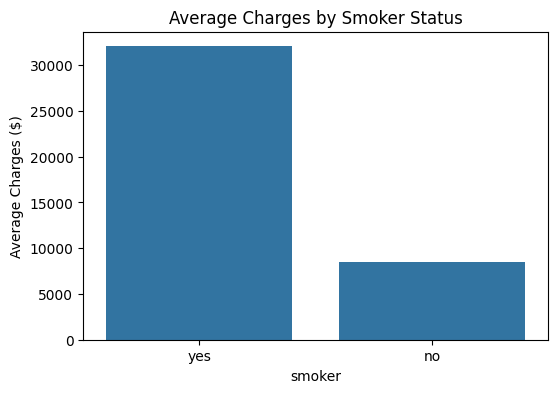

In [9]:
result = pd.read_sql(query1, conn)  # the smoker vs avg_charges query

plt.figure(figsize=(6,4))
sns.barplot(data=result, x='smoker', y='avg_charges')
plt.title("Average Charges by Smoker Status")
plt.ylabel("Average Charges ($)")
plt.show()